In [5]:
# All the imports 

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [ ]:
# Loading the dataset

df = pd.read_csv("../data/cs_students.csv")
df.head()

# Basic information + showing if there are missing values in the dataset

df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student ID         180 non-null    int64  
 1   Name               180 non-null    str    
 2   Gender             180 non-null    str    
 3   Age                180 non-null    int64  
 4   GPA                180 non-null    float64
 5   Major              180 non-null    str    
 6   Interested Domain  180 non-null    str    
 7   Projects           180 non-null    str    
 8   Future Career      180 non-null    str    
 9   Python             180 non-null    str    
 10  SQL                180 non-null    str    
 11  Java               180 non-null    str    
dtypes: float64(1), int64(2), str(9)
memory usage: 17.0 KB


Student ID           0
Name                 0
Gender               0
Age                  0
GPA                  0
Major                0
Interested Domain    0
Projects             0
Future Career        0
Python               0
SQL                  0
Java                 0
dtype: int64

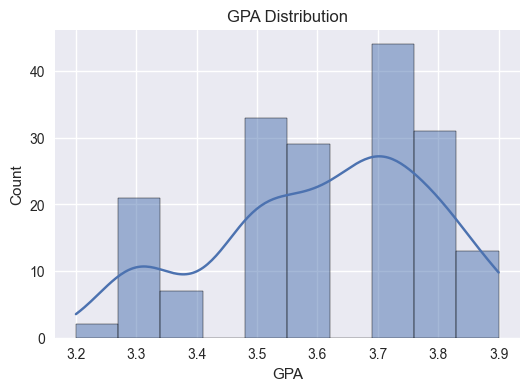

In [7]:
# Plotting the GPA Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["GPA"], bins=10, kde=True)
plt.title("GPA Distribution")
plt.show()

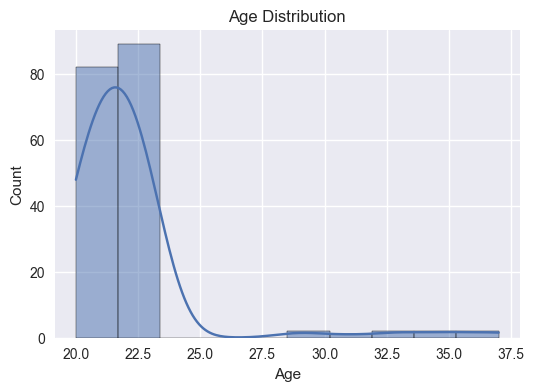

In [9]:
# Plotting the Age Distribution

plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=10, kde=True)
plt.title("Age Distribution")
plt.show()

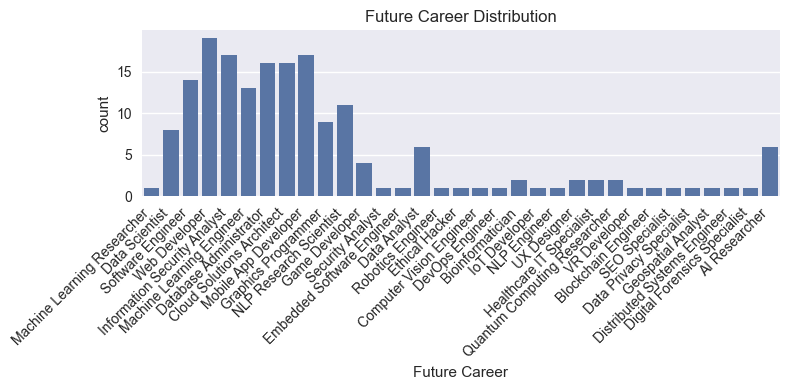

In [10]:
# Counting and plotting the future careers distribution

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Future Career")
plt.xticks(rotation=45, ha="right")
plt.title("Future Career Distribution")
plt.tight_layout()
plt.show()

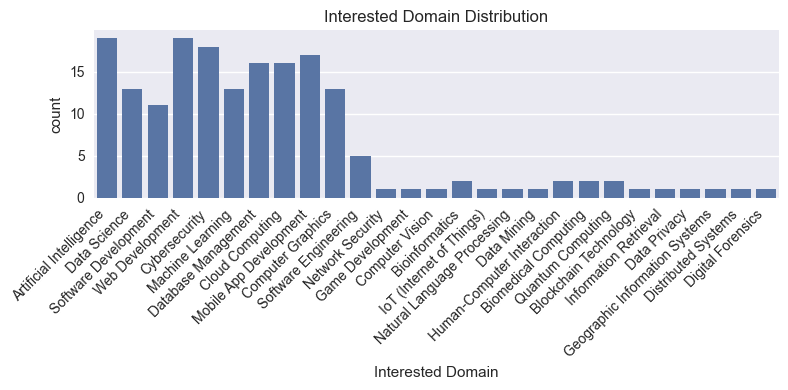

In [11]:
# Counting and plotting the interested domains distribution

plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Interested Domain")
plt.xticks(rotation=45, ha="right")
plt.title("Interested Domain Distribution")
plt.tight_layout()
plt.show()

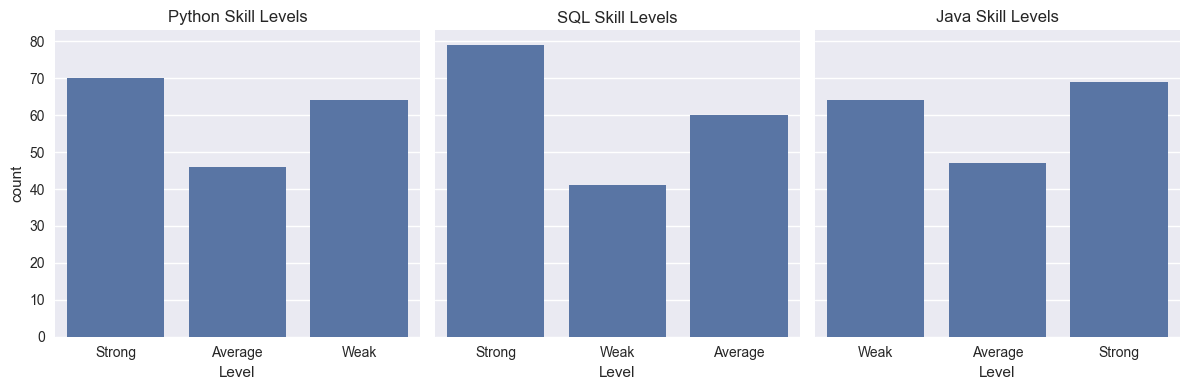

In [12]:
# Counting and plotting the skill level distribution

fig, axes = plt.subplots(1, 3, figsize=(12,4), sharey=True)

for ax, col in zip(axes, ["Python", "SQL", "Java"]):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"{col} Skill Levels")
    ax.set_xlabel("Level")

plt.tight_layout()
plt.show()


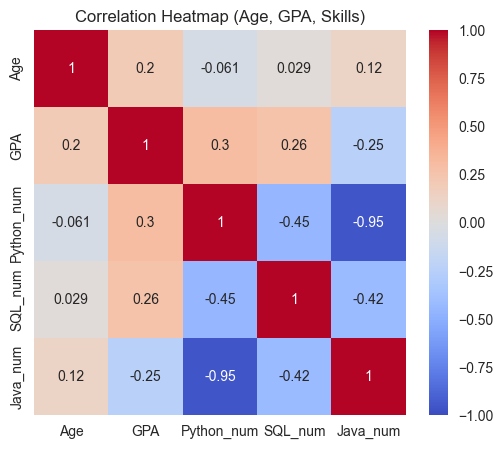

In [13]:
# Plotting the numeric mapping for the skill levels

skill_map = {"Weak": 1, "Moderate": 2, "Strong": 3}
df_corr = df.copy()
df_corr["Python_num"] = df_corr["Python"].map(skill_map)
df_corr["SQL_num"] = df_corr["SQL"].map(skill_map)
df_corr["Java_num"] = df_corr["Java"].map(skill_map)

num_cols = ["Age", "GPA", "Python_num", "SQL_num", "Java_num"]
corr = df_corr[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Age, GPA, Skills)")
plt.show()
